# Supplemental Figure: Methodology Illustration at a Single Site

This notebook produces the supplemental figure showing step-by-step how:
1. Snow pillow runoff onset is derived from the SWE time series (95% of water-year maximum)
2. SAR runoff onset is derived from the C-band backscatter minimum
3. How the two compare — for both a **high-SWE year** (>50 cm) and a **medium-SWE year** (20-50 cm)

The analysis targets sites where:
- High-SWE years show positive timing offset (SAR onset after snow pillow onset)
- Medium-SWE years show near-zero timing offset

This demonstrates how SWE magnitude affects the accuracy of SAR-derived runoff onset timing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import xarray as xr
import geopandas as gpd
import rasterio
import easysnowdata
from global_snowmelt_runoff_onset.config import Config
import global_snowmelt_runoff_onset.processing as processing
import warnings
warnings.filterwarnings('ignore')

## Configuration and Data Loading

In [2]:
from pathlib import Path

config = Config('config/global_config_v9.txt')

# Figures and the input comparison dataset are scoped by dataset version so a v10
# run cannot overwrite the v9 figures. Switching versions = editing the path above.
VERSION = config.version
FIGURE_DIR = Path('figures') / VERSION
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
COMPARISON_NC = Path('comparison_datasets') / f'snotel_sar_differences_UPDATED_SNOTEL_LOCATIONS_andreq10cmSWEfor60days_{VERSION}.nc'

buffer_radius = 1000
fcf_thresh    = 50

SAS token is valid until 2026-03-29 17:56 UTC (567.8 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [3]:
StationsWUS = easysnowdata.automatic_weather_stations.StationCollection()
StationsWUS.get_entire_data_archive()

stations_WUS_raw_da = StationsWUS.entire_data_archive['WTEQ'].sel(
    time=slice('2014-10-01', '2024-09-30')
)

Geodataframe with all stations has been added to the Station object. Please use the .all_stations attribute to access.
Use the .get_data(stations=geodataframe/string/list,variables=string/list,start_date=str,end_date=str) method to fetch data for specific stations and variables.
Decompressing data...
Creating xarray.Dataset from the uncompressed data...
Done! Entire archive dataset has been added to the station object. Please use the .entire_data_archive attribute to access.


In [4]:
# ── Reproduce the same filtering pipeline from the manuscript ──
stations_WUS_da = stations_WUS_raw_da.where(stations_WUS_raw_da >= 0)

abs_diffs         = np.abs(stations_WUS_da.diff(dim='time'))
abs_diffs_forward = abs_diffs.shift(time=1)
abs_diffs_back    = abs_diffs.shift(time=-1)
jump_mask         = (abs_diffs_forward < 0.2) & (abs_diffs_back < 0.2)
stations_WUS_da   = stations_WUS_da.where(jump_mask)

window = 10
valid_mask    = ~np.isnan(stations_WUS_da)
rolling_valid = valid_mask.rolling(time=window * 2, center=True).sum()
stations_WUS_da = stations_WUS_da.where(rolling_valid >= window)

# Missing-data and seasonal-snow checks (same as main analysis)
def check_missing_data(group):
    nov_to_apr_mask      = group.time.dt.month.isin([11, 12, 1, 2, 3])
    filtered_group       = group.where(nov_to_apr_mask, drop=True)
    missing_data_counts  = filtered_group.isnull().sum(dim='time')
    missing_data         = missing_data_counts > 30
    valid_data           = ~np.isnan(group)

    def calc_location_gaps(location_data):
        valid_indices = ~np.isnan(location_data)
        if not np.any(valid_indices):
            return True
        valid_times = group.time.values[valid_indices]
        gaps = np.diff(valid_times)
        return np.any(gaps / np.timedelta64(1, 'D') > 10)

    large_gaps = xr.apply_ufunc(
        calc_location_gaps, group,
        input_core_dims=[['time']], vectorize=True, output_dtypes=[bool]
    )

    if valid_data.any():
        first_valid_idx = valid_data.argmax(dim='time')
        last_valid_idx  = valid_data[:, ::-1].argmax(dim='time')
        first_valid     = group.isel(time=first_valid_idx)
        last_valid      = group.isel(time=group.sizes['time'] - last_valid_idx - 1)
        improper_evolution = (first_valid > 0.1) | (last_valid > 0.1)
    else:
        improper_evolution = True

    columns_to_nan = missing_data | large_gaps | improper_evolution
    group[columns_to_nan] = np.nan
    return group

def check_seasonal_snow_swe(group):
    sufficient_swe  = (group >= 0.05).rolling(time=60, center=True, min_periods=55).sum()
    columns_to_keep = (sufficient_swe >= 55).any(dim='time')
    group[~columns_to_keep] = np.nan
    return group

stations_WUS_da = stations_WUS_da.groupby('WY').apply(check_missing_data)
stations_WUS_da = stations_WUS_da.groupby('WY').apply(check_seasonal_snow_swe)
stations_WUS_da

<xarray.DataArray 'WTEQ' (station: 969, time: 3652)> Size: 28MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(969, 3652))
Coordinates: (12/17)
  * time           (time) datetime64[ns] 29kB 2014-10-02 ... 2024-09-30
  * station        (station) <U12 47kB '1135_UT_SNTL' ... '915_ID_SNTL'
    name           (station) <U24 93kB 'Burts Miller Ranch' ... 'Schwartz Lake'
    network        (station) <U6 23kB 'SNOTEL' 'SNOTEL' ... 'SNOTEL' 'SNOTEL'
    elevation_m    (station) float64 8kB 2.438e+03 2.377e+03 ... 2.63e+03
    latitude       (station) float64 8kB 40.98 44.79 37.16 ... 40.28 42.3 44.85
    ...             ...
    beginDate      (station) datetime64[ns] 8kB 2009-10-01 ... 1995-09-26
    endDate        (station) datetime64[ns] 8kB 2026-03-05 ... 2026-03-05
    csvData        (station) bool 969B True True True True ... True True True
    geometry       (station) object 8kB POINT (-110.85075378417969 40.9849205...
    WY             (time) int64 29kB 2015 2015 2015 2015 ... 2024 2024 2024 2024
    DOWY           (time) int64 29kB 2 3 4 5 6 7 8 ... 361 362 363 364 365 366

In [5]:
# ── Pre-computed comparison dataset (snow pillow onset + SAR onset per WY) ──
runoff_onset_ds = xr.open_dataset(COMPARISON_NC).compute()
runoff_onset_ds

<xarray.Dataset> Size: 12MB
Dimensions:                       (station: 969, WY: 10, buffer_radius: 4,
                                   fcf: 10)
Coordinates: (12/16)
  * station                       (station) <U12 47kB '1135_UT_SNTL' ... '915...
    name                          (station) <U24 93kB 'Burts Miller Ranch' .....
    network                       (station) <U6 23kB 'SNOTEL' ... 'SNOTEL'
    elevation_m                   (station) float64 8kB 2.438e+03 ... 2.63e+03
    latitude                      (station) float64 8kB 40.98 44.79 ... 44.85
    longitude                     (station) float64 8kB -110.9 -112.1 ... -113.8
    ...                            ...
    beginDate                     (station) datetime64[ns] 8kB 2009-10-01 ......
    endDate                       (station) datetime64[ns] 8kB 2025-07-13 ......
    csvData                       (station) bool 969B True True ... True True
  * WY                            (WY) int64 80B 2015 2016 2017 ... 2023 2024
  * buffer_radius                 (buffer_radius) int64 32B 100 300 500 1000
  * fcf                           (fcf) int64 80B 10 20 30 40 50 60 70 80 90 100
Data variables: (12/15)
    station_max_SWE_timing        (station, WY) float32 39kB nan 186.0 ... 193.0
    station_max_SWE_value         (station, WY) float32 39kB nan ... 0.2769
    station_max_SWE_99pct_timing  (station, WY) float32 39kB nan 186.0 ... 194.0
    station_max_SWE_95pct_timing  (station, WY) float32 39kB nan 186.0 ... 196.0
    station_max_SWE_90pct_timing  (station, WY) float32 39kB nan 186.0 ... 197.0
    station_max_SWE_50pct_timing  (station, WY) float32 39kB nan 190.0 ... 226.0
    ...                            ...
    mean_fcf                      (station, buffer_radius, fcf) float32 155kB ...
    sar_minus_stations            (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_99pct               (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_95pct               (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_90pct               (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_50pct               (station, WY, buffer_radius, fcf) float32 2MB ...

Text(0, 0.5, 'elevation')

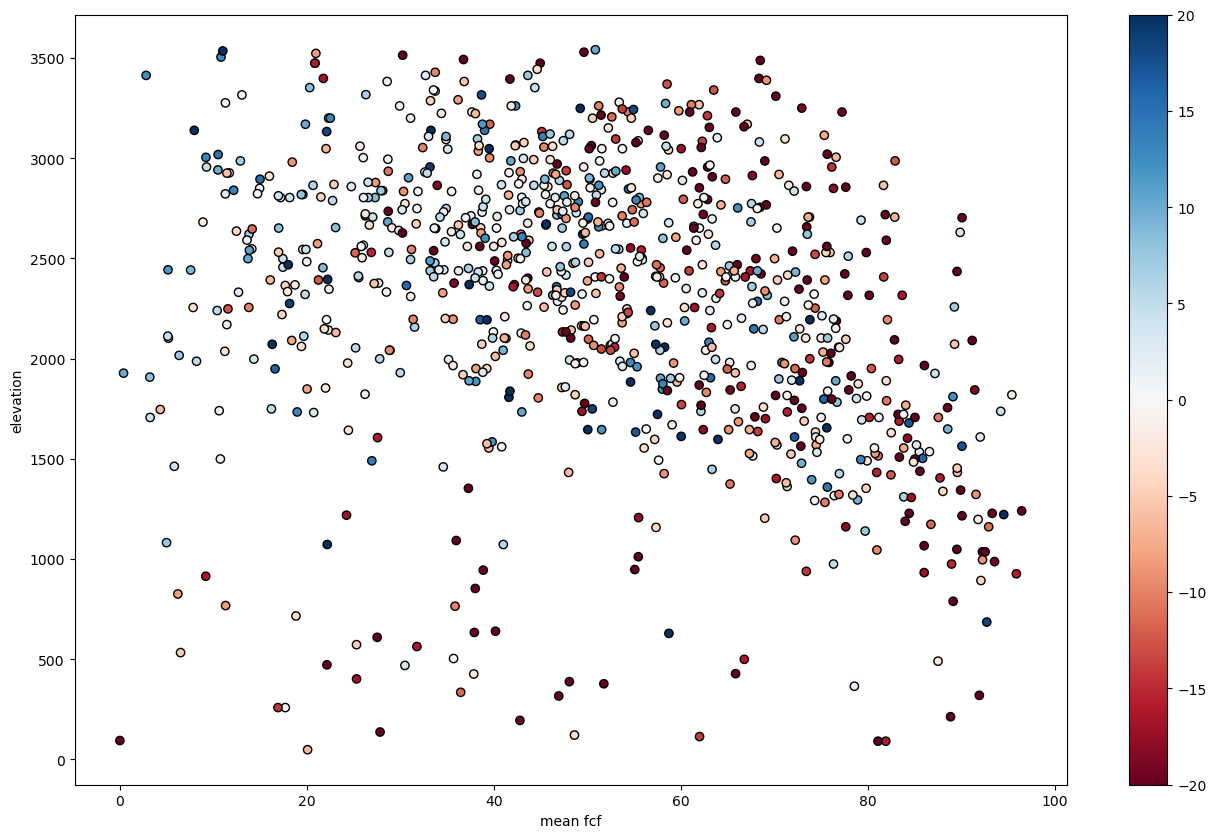

In [6]:
# plot mean fcf on x axis, elevation on y axis
elevations = runoff_onset_ds['elevation_m']
mean_fcf = runoff_onset_ds['mean_fcf'].sel(buffer_radius=1000,fcf=100)
var = runoff_onset_ds['station_max_SWE_value'].mean(dim='WY')
var = runoff_onset_ds['sar_minus_95pct'].sel(buffer_radius=1000,fcf=50).mean(dim='WY')
f,ax=plt.subplots(figsize=(16,10))
plotvar = ax.scatter(mean_fcf,elevations,c=var,vmin=-20,vmax=20,cmap='RdBu',edgecolors='black')

f.colorbar(plotvar)
ax.set_xlabel('mean fcf')
ax.set_ylabel('elevation')

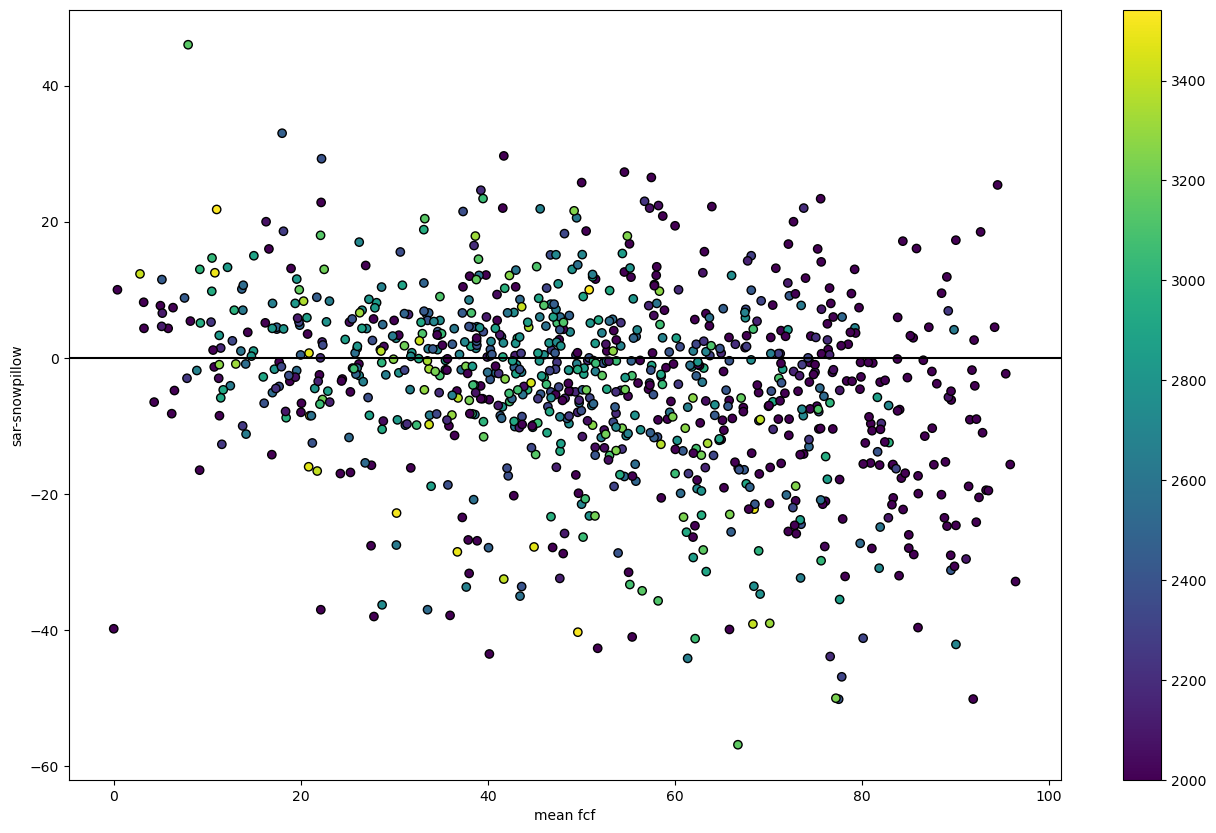

In [7]:
# plot saar_minus_95pct vs mean_fcf, color by elevation
elevations = runoff_onset_ds['elevation_m']
mean_fcf = runoff_onset_ds['mean_fcf'].sel(buffer_radius=1000,fcf=100)
var = runoff_onset_ds['station_max_SWE_value'].mean(dim='WY')
var = runoff_onset_ds['sar_minus_95pct'].sel(buffer_radius=1000,fcf=50).mean(dim='WY')
f,ax=plt.subplots(figsize=(16,10))
plotvar = ax.scatter(mean_fcf,var,c=elevations,edgecolors='black',vmin=2000)

f.colorbar(plotvar)
ax.set_xlabel('mean fcf')
ax.set_ylabel('sar-snowpillow')
ax.axhline(y=0,color='black')

In [9]:
# ── Pull the relevant slice from the precomputed dataset ──────────────────────
ds_sel = runoff_onset_ds.sel(fcf=fcf_thresh, buffer_radius=buffer_radius)

# Convert to a tidy DataFrame: one row per (station, WY)
df = ds_sel[['sar_minus_95pct', 'station_max_SWE_95pct_timing', 'mean_fcf', 'frac_valid_fcf']].to_dataframe().reset_index()


swe_var = [v for v in ds_sel.data_vars if 'max' in v.lower() and 'swe' in v.lower() and 'timing' not in v.lower()]
print('SWE magnitude variables found:', swe_var)

if swe_var:
    df['max_SWE'] = ds_sel[swe_var[0]].values.ravel()[:len(df)]
    df['max_SWE'] = ds_sel[swe_var[0]].to_dataframe().reset_index()['station_max_SWE_value'] # adjust col name as needed

df['abs_diff'] = np.abs(df['sar_minus_95pct'])
df = df.dropna(subset=['sar_minus_95pct', 'max_SWE'])

# ── For each station: find sites with desired characteristics ────────────────
# A station is a good candidate if:
#   1. Has at least `min_years` valid paired observations
#   2. Has a high-SWE year (>0.5m) with POSITIVE sar_minus_95pct
#   3. Has a medium-SWE year (0.2-0.5m) with sar_minus_95pct close to 0
#   4. Has meaningful SWE variability across years

min_years        = 3     # minimum number of valid WYs required
min_high_swe     = 0.60  # metres — high SWE threshold
min_medium_swe   = 0.20  # metres — medium SWE lower bound
max_medium_swe   = 0.60  # metres — medium SWE upper bound
max_median_diff  = 10    # days — exclude chronically bad stations
min_swe_range    = 0.2  # metres — station must have real interannual SWE variability

records = []
for station, grp in df.groupby('station'):
    grp = grp.dropna(subset=['max_SWE', 'sar_minus_95pct'])
    if len(grp) < min_years:
        continue
    if grp['abs_diff'].median() > max_median_diff:
        continue
    swe_range = grp['max_SWE'].max() - grp['max_SWE'].min()
    if swe_range < min_swe_range:
        continue

    # Find high-SWE year (>0.5m) with positive sar_minus_95pct
    high_swe_years = grp[grp['max_SWE'] > min_high_swe]
    high_pos_years = high_swe_years[high_swe_years['sar_minus_95pct'] > 0]
    
    if high_pos_years.empty:
        continue
    
    # Pick the one with largest positive difference among high SWE years
    best_high_row = high_pos_years.nlargest(1, 'sar_minus_95pct').iloc[0]

    # Find medium-SWE year (0.2-0.5m) with sar_minus_95pct close to 0
    medium_swe_years = grp[(grp['max_SWE'] >= min_medium_swe) & 
                           (grp['max_SWE'] <= max_medium_swe)]
    
    if medium_swe_years.empty:
        continue
    
    # Pick the one with sar_minus_95pct closest to 0
    medium_swe_years['abs_sar_minus_95pct'] = medium_swe_years['sar_minus_95pct'].abs()
    best_medium_row = medium_swe_years.nsmallest(1, 'abs_sar_minus_95pct').iloc[0]

    records.append(dict(
        station=station,
        n_years=len(grp),
        swe_range_m=round(swe_range, 3),
        median_abs_diff=round(grp['abs_diff'].median(), 1),
        high_swe_WY=int(best_high_row['WY']),
        high_swe_m=round(best_high_row['max_SWE'], 3),
        high_swe_sar_minus_95pct=round(best_high_row['sar_minus_95pct'], 1),
        medium_swe_WY=int(best_medium_row['WY']),
        medium_swe_m=round(best_medium_row['max_SWE'], 3),
        medium_swe_sar_minus_95pct=round(best_medium_row['sar_minus_95pct'], 1),
    ))

candidates = (
    pd.DataFrame(records)
    .set_index('station')
    .sort_values('high_swe_sar_minus_95pct', ascending=False)  # largest positive bias first
)

print(f'{len(candidates)} candidate stations found.\n')
print('Retrieving mean forest cover fraction for top 40 candidates from dataset...\n')

# ── Get mean FCF for top 40 candidates from precomputed dataset ──────────────
top_candidates = candidates.head(40).copy()
fcf_values = []
elevations = []

for i, station_code in enumerate(top_candidates.index, 1):
    #print(f'  [{i:2d}/40] {station_code}...', end=' ', flush=True)
    try:
        mean_fcf = float(runoff_onset_ds['mean_fcf'].sel(
            buffer_radius=buffer_radius, 
            fcf=100, 
            station=station_code
        ).values)
        fcf_values.append(mean_fcf)
        station_elevation=runoff_onset_ds['elevation_m'].sel(station=station_code).values
        elevations.append(np.round(station_elevation))
        #print(f'{mean_fcf:.1f}%')
    except Exception as e:
        print(f'Error: {e}')
        fcf_values.append(np.nan)

top_candidates['mean_fcf_pct'] = fcf_values
top_candidates['elevation'] = elevations

# Filter to sites with 30% or less FCF
top_candidates = top_candidates[top_candidates['mean_fcf_pct'] <= 30]

print(f'\nTop candidates with FCF ≤ 30% ({len(top_candidates)} sites):')
top_candidates

SWE magnitude variables found: ['station_max_SWE_value']
201 candidate stations found.

Retrieving mean forest cover fraction for top 40 candidates from dataset...


Top candidates with FCF ≤ 30% (10 sites):


,n_years,swe_range_m,median_abs_diff,high_swe_WY,high_swe_m,high_swe_sar_minus_95pct,medium_swe_WY,medium_swe_m,medium_swe_sar_minus_95pct,mean_fcf_pct,elevation
station,,,,,,,,,,,
EP5,9,1.987,5.0,2022,0.757,41.0,2015,0.295,-20.0,27.658245,2377.0
463_CA_SNTL,10,2.012,4.5,2022,0.757,34.0,2015,0.272,-22.0,28.500893,2333.0
570_NV_SNTL,10,0.574,7.0,2023,0.754,28.0,2020,0.254,0.0,21.709206,2454.0
626_UT_SNTL,10,0.904,4.0,2019,0.823,25.0,2018,0.404,1.0,28.653221,2995.0
652_NV_SNTL,10,1.933,7.5,2022,0.716,24.0,2015,0.444,4.0,28.637875,2683.0
SQV,9,1.631,9.0,2021,0.635,21.0,2015,0.472,-1.0,13.694057,2499.0
612_UT_SNTL,9,0.666,7.0,2019,0.734,21.0,2018,0.297,-2.0,23.062983,2655.0
784_CA_SNTL,10,1.636,10.0,2021,0.630,20.0,2015,0.467,-11.0,7.567678,2442.0
946_AK_SNTL,9,0.401,6.0,2021,0.709,19.0,2017,0.323,1.0,18.826977,716.0


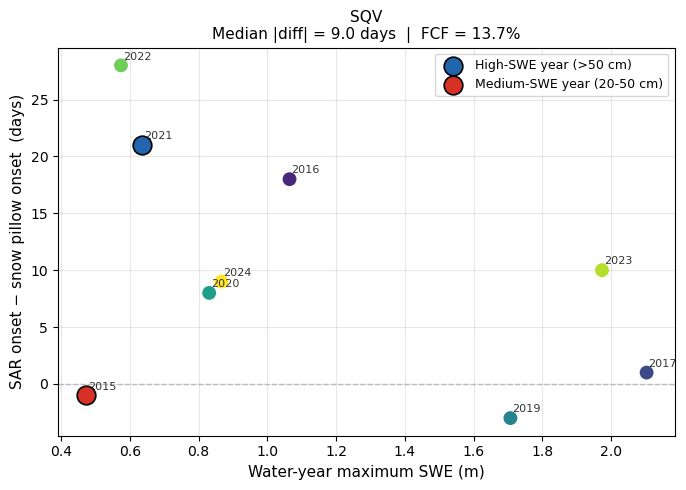


>>> Suggested settings for the supplemental figure:
    station_code  = 'SQV'
    high_swe_wy      = 2021   # max SWE = 0.6349999904632568 m, SAR-SP = +21.0 days
    medium_swe_wy    = 2015   # max SWE = 0.47200000286102295 m, SAR-SP = -1.0 days


In [10]:

# ── Visualise the pattern at the top candidate ────────────────────────────────
station_code = candidates.index[0]
station_code = '1222_UT_SNTL'
#station_code = '940_CO_SNTL'
#station_code = '570_NV_SNTL'
#station_code = '423_ID_SNTL'
station_code = 'SQV'
#station_code= '314_WY_SNTL'
#station_code='626_UT_SNTL'
top = candidates.loc[station_code]

# Check if FCF was computed for this station
fcf_text = ''
if station_code in top_candidates.index and 'mean_fcf_pct' in top_candidates.columns:
    mean_fcf = top_candidates.loc[station_code, 'mean_fcf_pct']
    if not np.isnan(mean_fcf):
        fcf_text = f'  |  FCF = {mean_fcf:.1f}%'

grp = df[df['station'] == station_code].sort_values('max_SWE')

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(grp['max_SWE'], grp['sar_minus_95pct'],
                c=grp['WY'], cmap='viridis', s=80, zorder=3)

# Annotate each point with its water year
for _, row in grp.iterrows():
    ax.text(row['max_SWE'] + 0.005, row['sar_minus_95pct'] + 0.5,
            str(int(row['WY'])), fontsize=8, color='#333333')

# Highlight the two chosen years
for wy_key, color, label in [
    (top['high_swe_WY'], '#2166ac', 'High-SWE year (>50 cm)'),
    (top['medium_swe_WY'],  '#d73027', 'Medium-SWE year (20-50 cm)')
]:
    row = grp[grp['WY'] == wy_key].iloc[0]
    ax.scatter(row['max_SWE'], row['sar_minus_95pct'],
               s=180, color=color, zorder=5, label=label,
               edgecolors='black', linewidths=1.2)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
ax.set_xlabel('Water-year maximum SWE (m)', fontsize=11)
ax.set_ylabel('SAR onset − snow pillow onset  (days)', fontsize=11)
ax.set_title(f'{station_code}\nMedian |diff| = {top["median_abs_diff"]} days{fcf_text}',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n>>> Suggested settings for the supplemental figure:")
print(f"    station_code  = '{station_code}'")
print(f"    high_swe_wy      = {int(top['high_swe_WY'])}   # max SWE = {top['high_swe_m']} m, SAR-SP = {top['high_swe_sar_minus_95pct']:+.1f} days")
print(f"    medium_swe_wy    = {int(top['medium_swe_WY'])}   # max SWE = {top['medium_swe_m']} m, SAR-SP = {top['medium_swe_sar_minus_95pct']:+.1f} days")

In [ ]:
# ── USER SETTINGS ──────────────────────────────────────────────────────────────
# Choose a station that has both a high-SWE year and a medium-SWE year with desired characteristics.
# Run the cell above to see suggested candidates.
#station_code      = candidates.index[0] if len(candidates) > 0 else '846_CA_SNTL'

# Water years to illustrate. These will be auto-populated from the candidate analysis above.
high_swe_wy     = candidates.loc[station_code, 'high_swe_WY'] #if len(candidates) > 0 else 2017    # >50cm SWE, positive SAR-SP offset
medium_swe_wy     = candidates.loc[station_code, 'medium_swe_WY'] #if len(candidates) > 0 else 2021  # 20-50cm SWE, ~0 offset
# ───────────────────────────────────────────────────────────────────────────────

In [ ]:
station_ds = runoff_onset_ds.sel(
    station=station_code,
    buffer_radius=buffer_radius,
    fcf=fcf_thresh
)
station_ds

In [ ]:
# Keep raw SWE for a single station (used to show unfiltered signal)
raw_swe = stations_WUS_raw_da.sel(station=station_code).where(
    stations_WUS_raw_da.sel(station=station_code) >= 0
)

filtered_swe = stations_WUS_da.sel(station=station_code)

In [ ]:
# ── Station location geometry (for clipping SAR data) ──
stations_gdf = gpd.read_file(
    '~/repos/updated_snotel_locations/snotel_stations_with_updated_locations.geojson'
).set_index('code')

def get_station_gdf(stations_gdf, station_code, buffer_radius=None):
    station_gdf   = stations_gdf[stations_gdf.index == station_code]
    station_epsg  = station_gdf.estimate_utm_crs().to_epsg()
    station_gdf   = station_gdf.to_crs(epsg=station_epsg)
    if buffer_radius:
        station_gdf['geometry'] = station_gdf.geometry.buffer(buffer_radius)
    return station_gdf

station_gdf = get_station_gdf(stations_gdf, station_code, buffer_radius)

In [ ]:
# ── Sentinel-1 C-band SAR backscatter (VV) ──
runoff_onset_global_ds   = config.open_runoff_onset_dataset()
runoff_onset_station_ds  = runoff_onset_global_ds.rio.clip_box(
    *station_gdf.total_bounds, crs=station_gdf.crs
).rio.reproject(station_gdf.crs)

s1_rtc_ds       = processing.get_sentinel1_rtc(runoff_onset_station_ds.odc.geobox)
backscatter_da   = s1_rtc_ds.median(dim=['x', 'y']).compute()
backscatter_dB   = 10 * np.log10(backscatter_da)
vv_dB            = backscatter_dB['vv']
print('SAR data loaded.')

## Helper functions

In [ ]:
def wy_slice(wy):
    """Return a time-slice string tuple for a water year."""
    return f'{wy-1}-10-01', f'{wy}-09-30'


def get_swe_for_wy(da, wy):
    """Return SWE DataArray for a single water year."""
    return da.sel(time=slice(*wy_slice(wy)))


def compute_snow_pillow_onset(swe_da):
    """
    Replicate the manuscript method:
    Last day when SWE >= 95% of the water-year maximum.

    Returns
    -------
    onset_date  : pd.Timestamp or None
    max_swe     : float  (m)
    threshold   : float  (m)
    """
    swe_vals = swe_da.values
    times    = pd.to_datetime(swe_da.time.values)

    if np.all(np.isnan(swe_vals)):
        return None, np.nan, np.nan

    max_swe   = np.nanmax(swe_vals)
    threshold = 0.95 * max_swe

    # Last index where SWE is still at or above the threshold
    above = np.where(swe_vals >= threshold)[0]
    if len(above) == 0:
        return None, max_swe, threshold

    last_idx    = above[-1]
    onset_date  = times[last_idx]
    return onset_date, max_swe, threshold


def get_sar_for_wy(vv_dB, wy):
    """Return VV backscatter for a single water year, one series per relative orbit."""
    start, end = wy_slice(wy)
    wy_mask    = (pd.to_datetime(vv_dB.time.values) >= pd.Timestamp(start)) & \
                 (pd.to_datetime(vv_dB.time.values) <= pd.Timestamp(end))
    return vv_dB.isel(time=wy_mask)


def compute_sar_onset(vv_wy_da):
    """
    Derive the SAR runoff onset date as the date of the minimum VV backscatter
    within the water year, averaged across all relative orbits.

    Returns
    -------
    onset_date : pd.Timestamp or None
    min_dB     : float
    """
    times  = pd.to_datetime(vv_wy_da.time.values)
    vals   = vv_wy_da.values

    if np.all(np.isnan(vals)):
        return None, np.nan

    min_idx    = np.nanargmin(vals)
    onset_date = times[min_idx]
    min_dB     = vals[min_idx]
    return onset_date, min_dB


def dowy_to_date(dowy, wy):
    """Convert a day-of-water-year integer to a calendar date."""
    wy_start = pd.Timestamp(year=wy - 1, month=10, day=1)
    return wy_start + pd.Timedelta(days=int(dowy) - 1)

## Compute onset dates for the two chosen water years

In [ ]:
results = {}

for wy, label in [(high_swe_wy, 'high_swe'), (medium_swe_wy, 'medium_swe')]:
    swe_wy = get_swe_for_wy(filtered_swe, wy)
    raw_wy = get_swe_for_wy(raw_swe,      wy)
    vv_wy  = get_sar_for_wy(vv_dB,        wy)

    sp_onset, max_swe, threshold = compute_snow_pillow_onset(swe_wy)
    sar_onset, min_dB            = compute_sar_onset(vv_wy)

    diff_days = None
    if sp_onset is not None and sar_onset is not None:
        diff_days = (sar_onset - sp_onset).days

    results[label] = dict(
        wy=wy, swe_wy=swe_wy, raw_wy=raw_wy, vv_wy=vv_wy,
        sp_onset=sp_onset, max_swe=max_swe, threshold=threshold,
        sar_onset=sar_onset, min_dB=min_dB,
        diff_days=diff_days
    )

    print(f"WY {wy} ({label}):")
    print(f"  Snow pillow onset : {sp_onset}  (SWE max={max_swe:.3f} m, threshold={threshold:.3f} m)")
    print(f"  SAR onset         : {sar_onset}  (min VV = {min_dB:.2f} dB)")
    print(f"  Difference        : {diff_days} days (SAR minus snow pillow)\n")

## Build the supplemental figure

Layout: **2 columns × 3 rows**
- Column 1 = high-SWE year (>50 cm), Column 2 = medium-SWE year (20-50 cm)
- Row 1 = Snow pillow SWE (raw + filtered, 95% threshold, onset marked)
- Row 2 = C-band SAR VV backscatter per orbit (minimum / onset marked)
- Row 3 = Timeline comparison (both onset dates, difference labelled)

In [ ]:
# ── Colour palette ────────────────────────────────────────────────────────────
COL_RAW       = '#b0b0b0'      # raw / unfiltered SWE
COL_FILTERED  = '#2166ac'      # filtered SWE
COL_THRESH    = '#d73027'      # 95% threshold line
COL_SP_ONSET  = '#d73027'      # snow pillow onset marker
COL_SAR_ONSET = '#4dac26'      # SAR onset marker
COL_SAR_MIN   = '#4dac26'      # SAR minimum dot
ORBIT_COLORS  = ['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a']

YEAR_LABELS   = {high_swe_wy: 'High-SWE year (>50 cm)', medium_swe_wy: 'Medium-SWE year (20-50 cm)'}


def plot_swe_panel(ax, r):
    """Row 1: raw + filtered SWE with 95% threshold and onset marker."""
    times_raw = pd.to_datetime(r['raw_wy'].time.values)
    times_flt = pd.to_datetime(r['swe_wy'].time.values)

    ax.plot(times_raw, r['raw_wy'].values,
            color=COL_RAW, lw=1.0, alpha=0.7, label='Raw SWE', zorder=1)
    ax.plot(times_flt, r['swe_wy'].values,
            color=COL_FILTERED, lw=1.8, label='Filtered SWE', zorder=2)

    if not np.isnan(r['threshold']):
        ax.axhline(r['threshold'], color=COL_THRESH, lw=1.4, ls='--',
                   label=f"95% of peak ({r['threshold']:.2f} m)", zorder=3)

    if r['sp_onset'] is not None:
        swe_at_onset = r['swe_wy'].sel(time=r['sp_onset'].strftime('%Y-%m-%d'),
                                        method='nearest').values
        ax.axvline(r['sp_onset'], color=COL_SP_ONSET, lw=2.0, ls='-',
                   label=f"Snow pillow onset ({r['sp_onset'].strftime('%b %d')})",
                   zorder=4)
        ax.plot(r['sp_onset'], float(swe_at_onset),
                'v', color=COL_SP_ONSET, ms=10, zorder=5)

    ax.set_ylabel('SWE (m)', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(True, alpha=0.3)


def plot_sar_panel(ax, r):
    """Row 2: SAR VV backscatter per relative orbit, minimum onset marker."""
    vv = r['vv_wy']

    if 'sat:relative_orbit' in vv.coords:
        unique_orbits = np.unique(vv['sat:relative_orbit'].values)
        for i, rel_orbit in enumerate(unique_orbits):
            mask  = vv['sat:relative_orbit'] == rel_orbit
            sub   = vv.isel(time=mask)
            orbit_state = sub['sat:orbit_state'].values[0]
            tod   = 'afternoon' if orbit_state == 'ascending' else 'morning'
            color = ORBIT_COLORS[i % len(ORBIT_COLORS)]
            ax.plot(pd.to_datetime(sub.time.values), sub.values,
                    color=color, lw=1.2, alpha=0.85,
                    label=f'Orbit {rel_orbit} ({orbit_state}, {tod})')
    else:
        ax.plot(pd.to_datetime(vv.time.values), vv.values,
                color=ORBIT_COLORS[0], lw=1.2)

    if r['sar_onset'] is not None:
        ax.axvline(r['sar_onset'], color=COL_SAR_ONSET, lw=2.0, ls='-',
                   label=f"SAR minimum ({r['sar_onset'].strftime('%b %d')})",
                   zorder=4)
        ax.plot(r['sar_onset'], r['min_dB'],
                'v', color=COL_SAR_ONSET, ms=10, zorder=5)

    ax.set_ylabel('VV backscatter (dB)', fontsize=10)
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(True, alpha=0.3)


def plot_timeline_panel(ax, r):
    """
    Row 3: Compact horizontal timeline showing both onset dates
    and the signed difference between them.
    """
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.grid(True, alpha=0.3, axis='x')

    # Shade the snow season as a light background
    wy = r['wy']
    ax.set_xlim(pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))

    y_sp  = 0.65
    y_sar = 0.35

    # Horizontal guide lines
    ax.axhline(y_sp,  color=COL_SP_ONSET,  lw=0.8, ls=':', alpha=0.6)
    ax.axhline(y_sar, color=COL_SAR_ONSET, lw=0.8, ls=':', alpha=0.6)

    ax.text(pd.Timestamp(f'{wy-1}-10-05'), y_sp  + 0.07,
            'Snow pillow onset', color=COL_SP_ONSET,  fontsize=9, va='bottom')
    ax.text(pd.Timestamp(f'{wy-1}-10-05'), y_sar - 0.07,
            'SAR minimum',       color=COL_SAR_ONSET, fontsize=9, va='top')

    if r['sp_onset'] is not None:
        ax.axvline(r['sp_onset'], color=COL_SP_ONSET, lw=2.5, zorder=4)
        ax.plot(r['sp_onset'], y_sp, 'o', color=COL_SP_ONSET, ms=10, zorder=5)
        ax.text(r['sp_onset'], y_sp - 0.05,
                r['sp_onset'].strftime('%b %d'),
                ha='center', va='top', fontsize=8, color=COL_SP_ONSET)

    if r['sar_onset'] is not None:
        ax.axvline(r['sar_onset'], color=COL_SAR_ONSET, lw=2.5, zorder=4)
        ax.plot(r['sar_onset'], y_sar, 'o', color=COL_SAR_ONSET, ms=10, zorder=5)
        ax.text(r['sar_onset'], y_sar + 0.05,
                r['sar_onset'].strftime('%b %d'),
                ha='center', va='bottom', fontsize=8, color=COL_SAR_ONSET)

    # Arrow + difference label between the two dates
    if r['sp_onset'] is not None and r['sar_onset'] is not None:
        x1  = r['sp_onset']
        x2  = r['sar_onset']
        ymid = 0.5
        ax.annotate('', xy=(x2, ymid), xytext=(x1, ymid),
                    arrowprops=dict(arrowstyle='<->', color='#555555',
                                    lw=1.8, mutation_scale=14))
        mid_date  = x1 + (x2 - x1) / 2
        sign      = '+' if r['diff_days'] >= 0 else ''
        ax.text(mid_date, ymid + 0.05,
                f"{sign}{r['diff_days']} days\n(SAR − snow pillow)",
                ha='center', va='bottom', fontsize=9,
                color='#333333',
                bbox=dict(boxstyle='round,pad=0.25', fc='white',
                          ec='#aaaaaa', alpha=0.85))

    ax.set_ylim(0, 1)
    ax.set_xlabel('Date', fontsize=10)


# ── Assemble the figure ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    f'Methodology illustration — {station_code}\n'
    f'Snow pillow runoff onset (95% SWE threshold) vs. C-band SAR backscatter minimum',
    fontsize=13, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(
    nrows=3, ncols=2,
    hspace=0.35, wspace=0.20,
    height_ratios=[2.2, 2.2, 1.0]
)

row_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
panel_idx  = 0

col_titles = [f"High-SWE year (>50 cm)  —  WY {high_swe_wy}", f"Medium-SWE year (20-50 cm)  —  WY {medium_swe_wy}"]
row_titles = [
    'Row 1  |  Snow pillow SWE',
    'Row 2  |  SAR VV backscatter',
    'Row 3  |  Onset date comparison'
]

axes = [[None, None], [None, None], [None, None]]

for col_i, label in enumerate(['high_swe', 'medium_swe']):
    r = results[label]
    wy = r['wy']
    xlim = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))

    # Row 0 — SWE
    ax0 = fig.add_subplot(gs[0, col_i])
    plot_swe_panel(ax0, r)
    ax0.set_xlim(xlim)
    ax0.set_xlabel('')
    ax0.set_title(col_titles[col_i], fontsize=11, fontweight='bold', pad=6)
    ax0.text(0.01, 0.97, row_labels[panel_idx], transform=ax0.transAxes,
             fontsize=10, fontweight='bold', va='top')
    axes[0][col_i] = ax0
    panel_idx += 1

    # Row 1 — SAR
    ax1 = fig.add_subplot(gs[1, col_i], sharex=ax0)
    plot_sar_panel(ax1, r)
    ax1.set_xlim(xlim)
    ax1.set_xlabel('')
    ax1.text(0.01, 0.97, row_labels[panel_idx], transform=ax1.transAxes,
             fontsize=10, fontweight='bold', va='top')
    axes[1][col_i] = ax1
    panel_idx += 1

    # Row 2 — Timeline
    ax2 = fig.add_subplot(gs[2, col_i], sharex=ax0)
    plot_timeline_panel(ax2, r)
    ax2.set_xlim(xlim)
    axes[2][col_i] = ax2

# Shared y-axis ranges for each row across both columns
for row in range(2):
    ymins = [axes[row][c].get_ylim()[0] for c in range(2)]
    ymaxs = [axes[row][c].get_ylim()[1] for c in range(2)]
    for c in range(2):
        axes[row][c].set_ylim(min(ymins), max(ymaxs))

# Row labels on the left margin
for row_i, rtitle in enumerate(row_titles):
    axes[row_i][0].set_ylabel(
        axes[row_i][0].get_ylabel(), fontsize=10
    )

plt.savefig(FIGURE_DIR / 'supplemental_figure_methodology.pdf', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.savefig(FIGURE_DIR / 'supplemental_figure_methodology.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved.')

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import rioxarray as rxr
import pystac_client
import planetary_computer
import odc.stac
import geopandas as gpd
from shapely.geometry import box

COL_SP = '#d73027'

# ── Use local UTM as the working CRS (equal area at local scale) ──────────────
utm_crs    = station_gdf.estimate_utm_crs()
station_utm = station_gdf.to_crs(utm_crs)
centroid    = station_utm.geometry.centroid

# ── Compute zoomed square extent in UTM ───────────────────────────────────────
def get_zoomed_extent(station_utm, zoom_factor=1.6):
    minx, miny, maxx, maxy = station_utm.total_bounds
    cx   = (minx + maxx) / 2
    cy   = (miny + maxy) / 2
    half = max((maxx - minx), (maxy - miny)) / 2 * zoom_factor
    return cx - half, cy - half, cx + half, cy + half

ext = get_zoomed_extent(station_utm, zoom_factor=1.6)

# Build zoomed bbox in 4326 for raster fetching
zoomed_box_utm  = gpd.GeoDataFrame(geometry=[box(*ext)], crs=utm_crs)
zoomed_box_4326 = zoomed_box_utm.to_crs('EPSG:4326')

# ── Load FCF reprojected to UTM ───────────────────────────────────────────────
def load_fcf(zoomed_box_4326, utm_crs):
    fcf_da = rxr.open_rasterio(
        "https://zenodo.org/record/3939050/files/PROBAV_LC100_global_v3.0.1_2019-nrt_Tree-CoverFraction-layer_EPSG-4326.tif",
        chunks=True, mask_and_scale=True,
    )
    fcf_da = fcf_da.rio.clip_box(*zoomed_box_4326.total_bounds, crs='EPSG:4326').squeeze()
    return fcf_da.rio.reproject(utm_crs).compute()

# ── Load DEM reprojected to UTM ───────────────────────────────────────────────
def load_dem(zoomed_box_4326, utm_crs, resolution=30):
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace
    )
    search = catalog.search(
        collections=[f"cop-dem-glo-{resolution}"],
        bbox=zoomed_box_4326.total_bounds
    )
    dem_da = odc.stac.load(
        search.items(), bbox=zoomed_box_4326.total_bounds, chunks={}
    )['data'].squeeze()
    dem_da = dem_da.rio.write_nodata(-32767, encoded=True)
    return dem_da.rio.reproject(utm_crs).compute()

fcf_utm = load_fcf(zoomed_box_4326, utm_crs)
dem_utm = load_dem(zoomed_box_4326, utm_crs)

# ── Shared helpers ────────────────────────────────────────────────────────────
def apply_shared_extent(ax):
    ax.set_xlim(ext[0], ext[2])
    ax.set_ylim(ext[1], ext[3])
    ax.set_aspect('equal')
    ax.set_axis_off()

def overlay_buffer(ax):
    station_utm.boundary.plot(ax=ax, color=COL_SP, linewidth=2, zorder=5)
    ax.scatter(centroid.x, centroid.y, color=COL_SP, s=60,
               zorder=6, marker='+', linewidths=2)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
ax_sat, ax_fcf, ax_dem = axes

# Satellite — contextily accepts crs kwarg for non-3857 axes
overlay_buffer(ax_sat)
apply_shared_extent(ax_sat)
ctx.add_basemap(ax_sat, crs=utm_crs.to_string(),
                source=ctx.providers.Esri.WorldImagery,
                zoom='auto', attribution=False)

# FCF
xc = fcf_utm.x.values
yc = fcf_utm.y.values
im_fcf = ax_fcf.imshow(
    fcf_utm.values, origin='upper',
    extent=[xc.min(), xc.max(), yc.min(), yc.max()],
    cmap='YlGn', vmin=0, vmax=100, interpolation='nearest'
)
overlay_buffer(ax_fcf)
plt.colorbar(im_fcf, ax=ax_fcf, fraction=0.046, pad=0.04, label='FCF (%)')
apply_shared_extent(ax_fcf)
ax_fcf.set_title(f'Forest cover fraction',
                 fontsize=10, fontweight='bold', pad=6)

# DEM
xd = dem_utm.x.values
yd = dem_utm.y.values
im_dem = ax_dem.imshow(
    dem_utm.values, origin='upper',
    extent=[xd.min(), xd.max(), yd.min(), yd.max()],
    cmap='terrain', interpolation='bilinear'
)
overlay_buffer(ax_dem)
plt.colorbar(im_dem, ax=ax_dem, fraction=0.046, pad=0.04, label='Elevation (m)')
apply_shared_extent(ax_dem)
ax_dem.set_title('Copernicus DEM (30 m)', fontsize=10, fontweight='bold', pad=6)

ax_sat.set_title('Visual context', fontsize=10, fontweight='bold', pad=6)

plt.tight_layout()
plt.savefig(FIGURE_DIR / f'supplemental_figure_context_low_fcf_{station_code}.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURE_DIR / f'supplemental_figure_context_low_fcf_{station_code}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Context figure saved.')

In [ ]:
# ── Fetch temperature and wind data from AWDB REST API ───────────────────────
import requests

AWDB_BASE_URL = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1"

def parse_station_triplet(station_code):
    """Convert station_code like '940_CO_SNTL' to triplet format 'stationId:state:network'"""
    parts = station_code.split('_')
    if len(parts) == 3:
        station_id, state, network = parts
        return f"{station_id}:{state}:{network}"
    return station_code

def get_available_elements(station_code, duration="DAILY"):
    """Check what elements are available for this station."""
    triplet = parse_station_triplet(station_code)
    
    endpoint = "stations"
    params = {
        'stationTriplets': triplet,
        'returnStationElements': 'true',
        'durations': duration
    }
    
    url = f"{AWDB_BASE_URL}/{endpoint}"
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        
        if data and len(data) > 0:
            station = data[0]
            elements = station.get('stationDataTimeZone', {}).get('stationElements', [])
            if 'stationElements' in station:
                elements = station['stationElements']
            element_codes = [e.get('elementCd') for e in elements if e.get('duration') == duration]
            return element_codes
        return []
    except Exception as e:
        print(f"Error getting available elements: {e}")
        return []

def get_awdb_data(station_code, wy, elements, duration="DAILY", debug=False):
    """
    Fetch data from AWDB REST API for specific elements and water year.
    
    Parameters
    ----------
    station_code : str
        Station code like '940_CO_SNTL'
    wy : int
        Water year
    elements : list of str
        Element codes like ['TAVG', 'TMAX', 'TMIN', 'WSPDV']
    duration : str
        'DAILY' or other duration
    debug : bool
        Print debug information
        
    Returns
    -------
    pd.DataFrame
        DataFrame with time index and columns for each element
    """
    triplet = parse_station_triplet(station_code)
    
    # Define water year date range
    start_date = pd.Timestamp(f'{wy-1}-10-01')
    end_date   = pd.Timestamp(f'{wy}-09-30')
    
    endpoint = "data"
    element_str = ",".join(elements)
    
    params = {
        'stationTriplets': triplet,
        'elements': element_str,
        'duration': duration,
        'beginDate': start_date.strftime('%Y-%m-%d'),
        'endDate': end_date.strftime('%Y-%m-%d'),
    }
    
    url = f"{AWDB_BASE_URL}/{endpoint}"
    
    try:
        response = requests.get(url, params=params)
        
        if debug:
            print(f"  Request URL: {response.url}")
            print(f"  Status code: {response.status_code}")
        
        response.raise_for_status()
        data = response.json()
        
        if debug:
            print(f"  Response length: {len(data) if data else 0}")
            if data and len(data) > 0:
                print(f"  First item keys: {data[0].keys()}")
                if 'data' in data[0]:
                    print(f"  Number of elements: {len(data[0]['data'])}")
        
        if not data:
            if debug:
                print(f"  No data returned for {station_code} WY {wy}")
            return pd.DataFrame()
        
        # Parse response into DataFrame
        # Response structure: [{"stationTriplet": "...", "data": [{"elementCd": "...", "values": [...]}]}]
        dfs = []
        for station_response in data:
            # Get the data array from the station response
            element_data_list = station_response.get('data', [])
            
            if debug:
                print(f"  Processing {len(element_data_list)} elements")
            
            for element_data in element_data_list:
                # Extract element code from stationElement object
                station_element = element_data.get('stationElement', {})
                element_code = station_element.get('elementCode') if station_element else None
                values = element_data.get('values', [])
                
                if debug:
                    print(f"    Element: {element_code}, Values: {len(values)}")
                
                if not values or element_code is None:
                    continue
                    
                df = pd.DataFrame(values)
                df['date'] = pd.to_datetime(df['date'])
                df = df.set_index('date')
                df = df.rename(columns={'value': element_code})
                dfs.append(df[[element_code]])
        
        if not dfs:
            return pd.DataFrame()
            
        # Merge all elements
        result = pd.concat(dfs, axis=1)
        
        # Convert temperature from Fahrenheit to Celsius
        temp_cols = ['TOBS', 'TAVG', 'TMAX', 'TMIN']
        for col in temp_cols:
            if col in result.columns:
                result[col] = (result[col] - 32) * 5/9
        
        return result
        
    except Exception as e:
        print(f"  Error fetching data for {station_code} WY {wy}: {e}")
        if debug:
            import traceback
            traceback.print_exc()
        return pd.DataFrame()

# ── Check available elements first ───────────────────────────────────────────
print(f"Checking available elements for {station_code}...")
available = get_available_elements(station_code)
print(f"  Available DAILY elements: {available[:20] if len(available) > 20 else available}")

# ── Fetch temperature and wind data for both water years ─────────────────────
# Common SNOTEL element codes:
# TAVG = Average Temperature, TOBS = Observed Temperature
# TMAX = Maximum Temperature, TMIN = Minimum Temperature  
# WSPDV = Wind Speed Average, WSPDX = Wind Speed Maximum
temp_wind_elements = ['TOBS', 'TMAX', 'TMIN', 'WSPDV']

temp_wind_data = {}
for wy, label in [(high_swe_wy, 'high_swe'), (medium_swe_wy, 'medium_swe')]:
    print(f"\nFetching temperature and wind data for {station_code} WY {wy}...")
    df = get_awdb_data(station_code, wy, temp_wind_elements, debug=True)
    temp_wind_data[label] = df
    if not df.empty:
        print(f"  ✓ Retrieved: {', '.join(df.columns.tolist())}")
    else:
        print(f"  ✗ No data retrieved")

print("\nData fetch complete.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.legend_handler import HandlerBase

# ── Colours ───────────────────────────────────────────────────────────────────
COL_FILTERED = '#2166ac'
COL_THRESH   = '#f4a100'
COL_SP       = '#d73027'
COL_SAR      = '#111111'
COL_SAD      = '#984ea3'
COL_SDD      = '#ff7f00'
ORBIT_COLORS = ['#4393c3', '#74c476', '#969696', '#fdae6b', '#9ecae1']

SDD_OFFSET = pd.Timedelta(days=16)

# ── Custom legend handler: vertical line + triangle ───────────────────────────
class HandlerVLine(HandlerBase):
    """
    Renders a vertical line (with optional triangle marker) in the legend key.
    Line is drawn at full key height so it's clearly visible behind the marker.
    """
    def __init__(self, color, lw=0.5, ls='-', alpha=1.0,
                 marker=None, ms=5, marker_alpha=1.0, marker_pos=0.35):
        self._color        = color
        self._lw           = lw
        self._ls           = ls
        self._alpha        = alpha
        self._marker       = marker
        self._ms           = ms
        self._marker_alpha = marker_alpha
        self._marker_pos   = marker_pos
        super().__init__()

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        cx = xdescent + width / 2.0
        artists = []
        # Triangle drawn FIRST so the line renders on top of it


        # Line drawn SECOND so it sits on top of the triangle
# White backing line (drawn between triangle and colored line)
        vline_bg = plt.Line2D(
            [cx, cx], [ydescent - 2, ydescent + height + 2],
            color='white', linewidth=self._lw + 1.0, linestyle=self._ls,
            solid_capstyle='butt', transform=trans,
        )
        artists.append(vline_bg)
        # Colored line on top
        vline = plt.Line2D(
            [cx, cx], [ydescent - 2, ydescent + height + 2],
            color=self._color, linewidth=self._lw, linestyle=self._ls,
            alpha=self._alpha, solid_capstyle='butt', transform=trans,
        )
        artists.append(vline)
        
        if self._marker:
            my = ydescent + height * self._marker_pos        
            tri = plt.Line2D(
                [cx], [my], marker=self._marker,
                color=self._color, markersize=7,   # fixed size for all entries
                alpha=self._marker_alpha, linestyle='None',
                markeredgecolor='white', markeredgewidth=0.6,
                transform=trans,
            )
            artists.append(tri)
            
        return artists


def vline_entry(label, color, lw=1.5, ls='-', alpha=1.0,
                marker=None, ms=5, marker_alpha=1.0, marker_pos=0.35):
    proxy = mlines.Line2D([], [], color=color, lw=lw, linestyle=ls,
                          alpha=alpha, label=label)
    handler = HandlerVLine(color=color, lw=lw, ls=ls, alpha=alpha,
                           marker=marker, ms=ms,
                           marker_alpha=marker_alpha, marker_pos=marker_pos)
    return proxy, handler


# ── MODIS seasonal snow mask ──────────────────────────────────────────────────
bbox_gdf = station_gdf
seasonal_snow_mask = xr.open_zarr(
    config.snow_phenology_store, consolidated=True, decode_coords='all'
)
seasonal_snow_mask_clip_ds = seasonal_snow_mask.rio.clip_box(
    *bbox_gdf.total_bounds, crs=bbox_gdf.crs
)

MODIS_SDD_DOWY = seasonal_snow_mask_clip_ds['SDD_DOWY'].median(dim=['x', 'y']).values
MODIS_SAD_DOWY = seasonal_snow_mask_clip_ds['SAD_DOWY'].median(dim=['x', 'y']).values

WY_all    = seasonal_snow_mask_clip_ds['SDD_DOWY'].water_year.values
WY_starts = [pd.Timestamp(year=int(y) - 1, month=10, day=1) for y in WY_all]
SAD_dates = {int(WY_all[i]): WY_starts[i] + pd.Timedelta(MODIS_SAD_DOWY[i] - 1, 'days')
             for i in range(len(WY_all))}
SDD_dates = {int(WY_all[i]): WY_starts[i] + pd.Timedelta(MODIS_SDD_DOWY[i] - 1, 'days')
             for i in range(len(WY_all))}

# ── SAR helpers ───────────────────────────────────────────────────────────────
def get_sar_for_wy(vv_dB, wy):
    start = pd.Timestamp(f'{wy-1}-10-01')
    end   = pd.Timestamp(f'{wy}-09-30')
    mask  = (pd.to_datetime(vv_dB.time.values) >= start) & \
            (pd.to_datetime(vv_dB.time.values) <= end)
    return vv_dB.isel(time=mask)


def compute_sar_onset(vv_wy_da, sad_date, sdd_date):
    if sad_date is None or sdd_date is None:
        return None, np.nan, []

    sdd_adjusted  = sdd_date + SDD_OFFSET
    snow_midpoint = sad_date + (sdd_adjusted - sad_date) / 2
    times         = pd.to_datetime(vv_wy_da.time.values)
    vals          = vv_wy_da.values
    orbit_results = []

    if 'sat:relative_orbit' in vv_wy_da.coords:
        orbits = np.unique(vv_wy_da['sat:relative_orbit'].values)
        for i, rel_orbit in enumerate(orbits):
            mask_orbit  = (vv_wy_da['sat:relative_orbit'] == rel_orbit).values
            sub_times   = times[mask_orbit]
            sub_vals    = vals[mask_orbit]
            window_mask = (sub_times >= snow_midpoint) & (sub_times <= sdd_adjusted)
            if not np.any(window_mask) or np.all(np.isnan(sub_vals[window_mask])):
                continue
            w_times = sub_times[window_mask]
            w_vals  = sub_vals[window_mask]
            min_idx = np.nanargmin(w_vals)
            orbit_results.append({
                'orbit': rel_orbit,
                'date':  w_times[min_idx],
                'dB':    w_vals[min_idx],
                'color': ORBIT_COLORS[i % len(ORBIT_COLORS)],
            })
    else:
        window_mask = (times >= snow_midpoint) & (times <= sdd_adjusted)
        if np.any(window_mask) and not np.all(np.isnan(vals[window_mask])):
            w_times = times[window_mask]
            w_vals  = vals[window_mask]
            min_idx = np.nanargmin(w_vals)
            orbit_results.append({'orbit': 0, 'date': w_times[min_idx],
                                  'dB': w_vals[min_idx], 'color': ORBIT_COLORS[0]})

    if not orbit_results:
        return None, np.nan, []

    ordinals    = [d['date'].toordinal() for d in orbit_results]
    median_ord  = int(np.median(ordinals))
    median_date = pd.Timestamp.fromordinal(median_ord)
    closest     = min(orbit_results, key=lambda d: abs(d['date'].toordinal() - median_ord))
    return median_date, closest['dB'], orbit_results


# ── Build result dicts ────────────────────────────────────────────────────────
r_high_swe     = {}
r_medium_swe   = {}

for r, wy in [(r_high_swe, high_swe_wy), (r_medium_swe, medium_swe_wy)]:
    r['wy']  = wy
    r['swe'] = get_swe_for_wy(filtered_swe, wy)
    r['vv']  = get_sar_for_wy(vv_dB, wy)
    r['sad'] = SAD_dates.get(wy)
    r['sdd'] = SDD_dates.get(wy)

    swe_vals  = r['swe'].values
    times_f   = pd.to_datetime(r['swe'].time.values)
    max_swe   = np.nanmax(swe_vals)
    threshold = 0.95 * max_swe
    above     = np.where(swe_vals >= threshold)[0]

    r['max_swe']   = max_swe
    r['threshold'] = threshold
    r['sp_onset']  = times_f[above[-1]] if len(above) else None

    r['sar_onset'], r['min_dB'], r['orbit_results'] = compute_sar_onset(
        r['vv'], r['sad'], r['sdd'])
    r['diff_days'] = (
        (r['sar_onset'] - r['sp_onset']).days
        if r['sp_onset'] is not None and r['sar_onset'] is not None else None
    )


# ── X-axis formatter ──────────────────────────────────────────────────────────
def apply_xaxis_fmt(ax, show_labels=True):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    if show_labels:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter(''))


# ── SWE panels ────────────────────────────────────────────────────────────────
def plot_swe_panel(ax, r, right=False):
    wy      = r['wy']
    xlim    = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))
    times_f = pd.to_datetime(r['swe'].time.values)

    ax.plot(times_f, r['swe'].values, color=COL_FILTERED, lw=1.8, zorder=2)
    ax.axhline(r['threshold'], color=COL_THRESH, lw=1.3, ls='--', zorder=3)

    if r['sp_onset'] is not None:
        ax.axvline(r['sp_onset'], color=COL_SP, lw=2.0, zorder=4)
        # Triangle hovers a fixed 0.05 m above the SWE peak
        marker_y = r['max_swe'] + 0.05
        ax.plot(r['sp_onset'], marker_y, 'v', color=COL_SP, ms=9, zorder=5)

    sp_proxy, sp_handler = vline_entry(
        label=f"Snow pillow onset "
              f"({r['sp_onset'].strftime('%b %d') if r['sp_onset'] else 'N/A'})",
        color=COL_SP, lw=2.0, marker='v', ms=4, marker_pos=0.50,
    )
    handles = [
        mlines.Line2D([], [], color=COL_FILTERED, lw=1.8, label='SWE'),
        mlines.Line2D([], [], color=COL_THRESH,   lw=1.3, ls='--',
                      label=f"95% of max SWE ({r['threshold']:.2f} m)"),
        sp_proxy,
    ]
    ax.legend(handles=handles, handler_map={sp_proxy: sp_handler},
              fontsize=8, loc='upper left', framealpha=0.85)
    ax.set_xlim(xlim)
    ax.set_ylim(bottom=0)
    ax.set_ylabel('SWE (m)', fontsize=10)
    ax.grid(True, alpha=0.3)
    apply_xaxis_fmt(ax, show_labels=False)

    if right:
        ax.yaxis.set_label_position('right')
        ax.yaxis.tick_right()


# ── Temperature panels ────────────────────────────────────────────────────────
def plot_temp_panel(ax, r, temp_df, right=False):
    """Row: Temperature with avg (or TOBS) as line and TMAX/TMIN as shaded envelope."""
    wy   = r['wy']
    xlim = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))
    
    if temp_df.empty:
        ax.text(0.5, 0.5, 'No temperature data available',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_xlim(xlim)
        ax.grid(True, alpha=0.3)
        apply_xaxis_fmt(ax, show_labels=False)
        return
    
    # Reindex to a full daily range so absent dates become NaN —
    # matplotlib will then break the line at any gap rather than skipping over it.
    full_index = pd.date_range(f'{wy-1}-10-01', f'{wy}-09-30', freq='D')
    temp_df = temp_df.reindex(full_index)
    
    # Calculate average from TMAX and TMIN if TOBS/TAVG not available
    if 'TOBS' not in temp_df.columns and 'TAVG' not in temp_df.columns:
        if 'TMAX' in temp_df.columns and 'TMIN' in temp_df.columns:
            temp_df = temp_df.copy()
            temp_df['TAVG'] = (temp_df['TMAX'] + temp_df['TMIN']) / 2
    
    # Plot average temperature as main line
    if 'TOBS' in temp_df.columns:
        avg_col = 'TOBS'
        avg_label = 'Observed temp'
    elif 'TAVG' in temp_df.columns:
        avg_col = 'TAVG'
        avg_label = 'Avg temp'
    else:
        avg_col = None
    
    if avg_col:
        # Matplotlib automatically breaks lines at NaN values
        avg_data = temp_df[avg_col]
        ax.plot(avg_data.index, avg_data.values, color='#377eb8', lw=1.8, 
                label=avg_label, zorder=3)
    
    # Plot TMAX and TMIN as shaded envelope
    if 'TMAX' in temp_df.columns and 'TMIN' in temp_df.columns:
        # Pass data WITH NaN values so fill_between leaves gaps where data is missing
        ax.fill_between(temp_df.index, 
                       temp_df['TMIN'], 
                       temp_df['TMAX'],
                       color='#377eb8', alpha=0.2, zorder=1,
                       label='Min/Max temp range')
    
    # 0°C reference line
    ax.axhline(0, color='black', lw=1.5, ls='--', alpha=0.6, 
               label='0°C', zorder=4)
    
    ax.set_xlim(xlim)
    ax.set_ylabel('Temperature (°C)', fontsize=10)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.85)
    ax.grid(True, alpha=0.3)
    apply_xaxis_fmt(ax, show_labels=False)
    
    if right:
        ax.yaxis.set_label_position('right')
        ax.yaxis.tick_right()


# ── Wind speed panels ─────────────────────────────────────────────────────────
def plot_wind_panel(ax, r, temp_df, right=False):
    """Row: Wind speed."""
    wy   = r['wy']
    xlim = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))
    
    if temp_df.empty or 'WSPDV' not in temp_df.columns:
        ax.text(0.5, 0.5, 'No wind speed data available',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_xlim(xlim)
        ax.grid(True, alpha=0.3)
        apply_xaxis_fmt(ax, show_labels=False)
        return

    # Reindex to a full daily range so absent dates become NaN (breaks lines at gaps)
    full_index = pd.date_range(f'{wy-1}-10-01', f'{wy}-09-30', freq='D')
    wind_data = temp_df['WSPDV'].reindex(full_index)
    
    ax.plot(wind_data.index, wind_data.values, color='#984ea3', lw=1.5, 
            label='Wind speed', zorder=2)
    
    ax.set_xlim(xlim)
    ax.set_ylabel('Wind speed (m/s)', fontsize=10)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.85)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    apply_xaxis_fmt(ax, show_labels=False)
    
    if right:
        ax.yaxis.set_label_position('right')
        ax.yaxis.tick_right()

        ax.yaxis.tick_right()
# ── SAR panels ────────────────────────────────────────────────────────────────
def plot_sar_panel(ax, r, right=False):
    wy           = r['wy']
    xlim         = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))
    vv           = r['vv']
    sad          = r['sad']
    sdd_adjusted = r['sdd'] + SDD_OFFSET if r['sdd'] is not None else None

    # ── Orbit time-series → right legend ─────────────────────────────────────
    orbit_handles = []
    if 'sat:relative_orbit' in vv.coords:
        for i, rel_orbit in enumerate(np.unique(vv['sat:relative_orbit'].values)):
            sub         = vv.isel(time=(vv['sat:relative_orbit'] == rel_orbit))
            orbit_state = sub['sat:orbit_state'].values[0]
            tod         = 'ascending, afternoon' if orbit_state == 'ascending' \
                          else 'descending, morning'
            color       = ORBIT_COLORS[i % len(ORBIT_COLORS)]
            ax.plot(pd.to_datetime(sub.time.values), sub.values,
                    color=color, lw=1.2, alpha=0.85, zorder=2)
            orbit_handles.append(mlines.Line2D([], [], color=color, lw=1.2,
                                               label=f'Orbit {rel_orbit} ({tod})'))
    else:
        ax.plot(pd.to_datetime(vv.time.values), vv.values,
                color=ORBIT_COLORS[0], lw=1.2, zorder=2)
        orbit_handles.append(mlines.Line2D([], [], color=ORBIT_COLORS[0],
                                           lw=1.2, label='VV backscatter'))

    leg_right = ax.legend(handles=orbit_handles, fontsize=8,
                          loc='lower right', framealpha=0.85)
    ax.add_artist(leg_right)

    # ── Per-orbit minima: dashed vlines + bigger triangles ───────────────────
    for orb in r['orbit_results']:
        ax.axvline(orb['date'], color=orb['color'], lw=1.4, ls='--',
                   alpha=0.65, zorder=3)
        ax.plot(orb['date'], orb['dB'], '^',
                color=orb['color'], ms=9, alpha=0.70, zorder=4,
                markeredgewidth=0.6, markeredgecolor='white')

    # ── Median minimum: bold black vline + larger triangle ────────────────────
    if r['sar_onset'] is not None:
        ax.axvline(r['sar_onset'], color=COL_SAR, lw=2.4, zorder=5)
        ax.plot(r['sar_onset'], r['min_dB'] - 1.0, '^',
                color=COL_SAR, ms=11, zorder=6,
                markeredgewidth=0.5, markeredgecolor='white')

    # ── Left legend: MODIS + search window + per-orbit + median ──────────────
    left_handles  = []
    left_handlers = {}

    if sad is not None:
        ax.axvline(sad, color=COL_SAD, lw=2.2, ls='--', zorder=3)
        p, h = vline_entry(f'Snow appearance ({sad.strftime("%b %d")})',
                           COL_SAD, lw=2.5, ls='--')
        left_handles.append(p); left_handlers[p] = h

    if sdd_adjusted is not None:
        ax.axvline(sdd_adjusted, color=COL_SDD, lw=2.2, ls='--', zorder=3)
        p, h = vline_entry(
            f'Snow disappearance +16 d ({sdd_adjusted.strftime("%b %d")})',
            COL_SDD, lw=2.5, ls='--')
        left_handles.append(p); left_handlers[p] = h

    if sad is not None and sdd_adjusted is not None:
        snow_midpoint = sad + (sdd_adjusted - sad) / 2
        ax.axvspan(snow_midpoint, sdd_adjusted, color='steelblue', alpha=0.12, zorder=1)
        left_handles.append(mpatches.Patch(facecolor='steelblue', alpha=0.35,
                                           label='Backscatter min search window'))

    # Per-orbit: dashed line, smaller centered triangle in legend
    p_orb, h_orb = vline_entry('Per-orbit backscatter min timing',
                                '#666666', lw=2.0, ls='--', alpha=0.75,
                                marker='^', ms=4, marker_alpha=0.8, marker_pos=0.50)
    left_handles.append(p_orb); left_handlers[p_orb] = h_orb

    # Median: bold black, smaller centered triangle in legend
    if r['sar_onset'] is not None:
        p_med, h_med = vline_entry(
            f"Median backscatter min timing ({r['sar_onset'].strftime('%b %d')})",
            COL_SAR, lw=2.0,
            marker='^', ms=6, marker_pos=0.50)
        left_handles.append(p_med); left_handlers[p_med] = h_med

    ax.legend(handles=left_handles, handler_map=left_handlers,
              fontsize=7, loc='lower left', framealpha=0.85)
    ax.add_artist(leg_right)

    ax.set_xlim(xlim)
    ax.set_ylabel('VV backscatter (dB)', fontsize=10)
    ax.grid(True, alpha=0.3)
    apply_xaxis_fmt(ax, show_labels=False)

    if right:
        ax.yaxis.set_label_position('right')
        ax.yaxis.tick_right()

        ax.yaxis.tick_right()
# ── Timeline panels ───────────────────────────────────────────────────────────
def plot_timeline_panel(ax, r, right=False):
    wy   = r['wy']
    xlim = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))

    ax.set_xlim(xlim)
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_ylabel('')

    y_sp  = 0.65
    y_sar = 0.35

    LABEL_OFFSET = pd.Timedelta(days=10)   # gap between vline and label text

    # horizontal guide lines intentionally omitted

    # ── Snow pillow onset: label RIGHT of the vline ───────────────────────────
    if r['sp_onset'] is not None:
        ax.axvline(r['sp_onset'], color=COL_SP, lw=2.5, zorder=4)
        ax.plot(r['sp_onset'], y_sp, 'v', color=COL_SP, ms=9, zorder=5)

        label_x = r['sp_onset'] + LABEL_OFFSET
        ax.text(label_x, y_sp + 0.16,
                'Snow pillow onset',
                ha='left', va='bottom', fontsize=9, color=COL_SP,
                fontweight='bold')
        ax.text(label_x, y_sp + 0.04,
                r['sp_onset'].strftime('%b %d'),
                ha='left', va='bottom', fontsize=9, color=COL_SP,
                fontweight='bold')

    # Per-orbit elements intentionally omitted from timeline panel

    # ── Median SAR onset: bold black vline + bigger triangle ──────────────────
    if r['sar_onset'] is not None:
        ax.axvline(r['sar_onset'], color=COL_SAR, lw=2.5, zorder=5)
        ax.plot(r['sar_onset'], y_sar, '^', color=COL_SAR, ms=11, zorder=6,
                markeredgewidth=0.5, markeredgecolor='white')

        # Label LEFT of the vline
        label_x = r['sar_onset'] - LABEL_OFFSET
        ax.text(label_x, y_sar - 0.03,
                'Median backscatter min timing',
                ha='right', va='top', fontsize=9, color=COL_SAR,
                fontweight='bold')
        ax.text(label_x, y_sar - 0.15,
                r['sar_onset'].strftime('%b %d'),
                ha='right', va='top', fontsize=9, color=COL_SAR,
                fontweight='bold')

    # ── Diff annotation arrow ─────────────────────────────────────────────────
    if r['sp_onset'] is not None and r['sar_onset'] is not None \
            and r['diff_days'] is not None:
        x1   = r['sp_onset']
        x2   = r['sar_onset']
        sign = '+' if r['diff_days'] >= 0 else ''
        # ax.annotate('', xy=(x2, 0.5), xytext=(x1, 0.5),
        #             arrowprops=dict(arrowstyle='<->', color='#555555',
        #                            lw=1.6, mutation_scale=13))

        # Text box: bottom-right corner of the panel
        box_x = xlim[1] - pd.Timedelta(days=10)
        ax.text(box_x, 0.08,
                f"timing offset of {r['diff_days']} days",
                ha='right', va='bottom', fontsize=10, color='#333333',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec='#aaaaaa', alpha=0.9))

    apply_xaxis_fmt(ax, show_labels=True)
    ax.set_xlabel('Date', fontsize=10)

    if right:
        ax.yaxis.set_label_position('right')

        ax.yaxis.set_label_position('right')
# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 14))

gs = gridspec.GridSpec(
    nrows=5, ncols=2,
    figure=fig,
    hspace=0.10, wspace=0.08,
    height_ratios=[2.0, 1.5, 1.5, 2.0, 0.85]
)

ax_swe_c  = fig.add_subplot(gs[0, 0])
ax_swe_a  = fig.add_subplot(gs[0, 1])
ax_temp_c = fig.add_subplot(gs[1, 0])
ax_temp_a = fig.add_subplot(gs[1, 1])
ax_wind_c = fig.add_subplot(gs[2, 0])
ax_wind_a = fig.add_subplot(gs[2, 1])
ax_sar_c  = fig.add_subplot(gs[3, 0])
ax_sar_a  = fig.add_subplot(gs[3, 1])
ax_tl_c   = fig.add_subplot(gs[4, 0])
ax_tl_a   = fig.add_subplot(gs[4, 1])

# ── Plot all panels ───────────────────────────────────────────────────────────
plot_swe_panel(ax_swe_c, r_high_swe,     right=False)
plot_swe_panel(ax_swe_a, r_medium_swe, right=True)

swe_ymax = max(ax_swe_c.get_ylim()[1], ax_swe_a.get_ylim()[1])
# Give a little headroom above peak SWE for the triangle marker
ax_swe_c.set_ylim(0, swe_ymax + 0.12)
ax_swe_a.set_ylim(0, swe_ymax + 0.12)

plot_temp_panel(ax_temp_c, r_high_swe,   temp_wind_data['high_swe'],   right=False)
plot_temp_panel(ax_temp_a, r_medium_swe, temp_wind_data['medium_swe'], right=True)

# Sync temperature y-limits
if not temp_wind_data['high_swe'].empty and not temp_wind_data['medium_swe'].empty:
    temp_ymin = min(ax_temp_c.get_ylim()[0], ax_temp_a.get_ylim()[0])
    temp_ymax = max(ax_temp_c.get_ylim()[1], ax_temp_a.get_ylim()[1])
    ax_temp_c.set_ylim(temp_ymin, temp_ymax)
    ax_temp_a.set_ylim(temp_ymin, temp_ymax)

plot_wind_panel(ax_wind_c, r_high_swe,   temp_wind_data['high_swe'],   right=False)
plot_wind_panel(ax_wind_a, r_medium_swe, temp_wind_data['medium_swe'], right=True)

# Sync wind speed y-limits
if not temp_wind_data['high_swe'].empty and not temp_wind_data['medium_swe'].empty:
    if 'WSPDV' in temp_wind_data['high_swe'].columns or 'WSPDV' in temp_wind_data['medium_swe'].columns:
        wind_ymax = max(ax_wind_c.get_ylim()[1], ax_wind_a.get_ylim()[1])
        ax_wind_c.set_ylim(0, wind_ymax)
        ax_wind_a.set_ylim(0, wind_ymax)

plot_sar_panel(ax_sar_c, r_high_swe,     right=False)
plot_sar_panel(ax_sar_a, r_medium_swe, right=True)

sar_ymin = min(ax_sar_c.get_ylim()[0], ax_sar_a.get_ylim()[0]) - 2
sar_ymax = max(ax_sar_c.get_ylim()[1], ax_sar_a.get_ylim()[1])
ax_sar_c.set_ylim(sar_ymin, sar_ymax)
ax_sar_a.set_ylim(sar_ymin, sar_ymax)

plot_timeline_panel(ax_tl_c, r_high_swe,     right=False)
plot_timeline_panel(ax_tl_a, r_medium_swe, right=True)

ax_swe_c.set_title(f'High-SWE year (WY {high_swe_wy})',    fontsize=12, fontweight='bold')
ax_swe_a.set_title(f'Medium-SWE year (WY {medium_swe_wy})', fontsize=12, fontweight='bold')

ax_swe_c.set_ylabel('SWE (m)', fontsize=10)
ax_temp_c.set_ylabel('Temperature (°C)', fontsize=10)
ax_wind_c.set_ylabel('Wind speed (m/s)', fontsize=10)
ax_sar_c.set_ylabel('VV backscatter (dB)', fontsize=10)

fig.suptitle(f'{station_code}, elevation:{np.round(runoff_onset_ds["elevation_m"].sel(station=station_code).values)}, mean fcf:{np.round(runoff_onset_ds["mean_fcf"].sel(station=station_code,buffer_radius=1000,fcf=100).values)}')

plt.savefig(FIGURE_DIR / f'supplemental_figure_timeseries_low_fcf_{station_code}_{high_swe_wy}_{medium_swe_wy}.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURE_DIR / f'supplemental_figure_timeseries_low_fcf_{station_code}_{high_swe_wy}_{medium_swe_wy}.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Time series figure saved.')

